In [11]:
#Import Library

import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pprint import pprint
from pysteps import io, nowcasts, rcparams
from pysteps.motion.lucaskanade import dense_lucaskanade
from pysteps.postprocessing import ensemblestats
from pysteps import io, nowcasts, rcparams, verification
from pysteps.postprocessing.ensemblestats import excprob
from pysteps.utils import conversion, dimension, transformation
from pysteps.visualization import plot_precip_field

import scipy.io
import os

In [12]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 24,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24
})

In [13]:
# Set nowcast parameters
n_ens_members = 10
n_leadtimes = 15
seed = 24

In [14]:
# Data source configuration
date_str = "20221109" 
date = datetime.strptime(date_str, "%Y%m%d")  # Convert string to datetime
root_path = "D:/College/MENEA/FIXED_DATA/RUN_TEST/"
output_directory = r"D:/College/MENEA/FIXED_DATA/OUTPUT/20221109/nowcasts/"

In [15]:
def load_santanu_data(date, root_path):
    # Construct the path to the folder containing the data for the given date
    date_folder = os.path.join(root_path, date.strftime("%Y%m%d"))
    
    if not os.path.exists(date_folder):
        raise FileNotFoundError(f"Folder {date_folder} does not exist.")
    
    R = []
    times = []
    
    for filename in os.listdir(date_folder):
        if filename.endswith('.mat'):
            file_path = os.path.join(date_folder, filename)
            mat_data = scipy.io.loadmat(file_path)
            
            # Print the keys of the loaded data for debugging
            print(f"Loaded data from {file_path}. Keys: {mat_data.keys()}")
            
            if 'ZI' not in mat_data:
                print(f"Warning: 'ZI' not found in file {file_path}. Skipping this file.")
                continue
            
            reflectivity = mat_data['ZI']
            reflectivity = reflectivity / 10000  # Divide by 10,000
            reflectivity[reflectivity == -1] = np.nan
           
            
            R.append(reflectivity)
            
            if 'f' not in mat_data or 't' not in mat_data:
                print(f"Warning: 'f' or 't' not found in file {file_path}. Skipping this file.")
                continue
            
            time_str = mat_data['f'][0][0]
            time = int(time_str)
            times.append(time)
    
    if not R:
        raise ValueError("No valid reflectivity data found in the specified folder.")
    
    # Create metadata manually
    metadata = {
        "institution": "Santanu",
        "accutime": 120,  # 2 minutes
        "unit": "mm/h",
        "transform": "dB",
        "zerovalue": 0,
        "threshold": 0.1,
        'x1': 107,  # Minimum x-coordinate (longitude) for Great Basin
        'x2': 108,  # Maximum x-coordinate (longitude) for Great Basin
        'y1': -7.2,    # Minimum y-coordinate (latitude) for Great Basin
        'y2': -6.4,    # Maximum y-coordinate (latitude) for Great Basin
        'lat': np.linspace(-7.2, -6.4, R[0].shape[0]),  # Latitude array
        'lon': np.linspace(107, 108, R[0].shape[1]),  # Longitude array
        'regular_grid': True,  # Assuming the data is on a regular grid
        'projection': "+proj=merc +lon_0=0 +datum=WGS84 +units=m +no_defs",
        'yorigin': 'upper',
        "xorigin": '',
        "ydim": 734,
        "xdim": 734,
        "yllcorner": 107,
        "xllcorner": -7.2,
        "xscale": 1000,  # Assuming 1 km resolution
        "yscale": 1000,
        "ypixelsize": 1000,  # Add this line
        "xpixelsize": 1000,  # Add this line
        "cartesian_map": True,
        'zr_a': 316.0,  # Z-R relationship parameter
        'zr_b': 1.5,    # Z-R relationship parameter
    }
    
    return np.array(R), np.array(times), metadata

# Example usage
R, times, metadata = load_santanu_data(date, root_path)

# Check the shape of R and metadata
print(f"Shape of R: {R.shape}")
print(f"Metadata: {metadata}")

Loaded data from D:/College/MENEA/FIXED_DATA/RUN_TEST/20221109\new_20221109_143612.mat. Keys: dict_keys(['__header__', '__version__', '__globals__', 't', 'f', 'ZI'])
Loaded data from D:/College/MENEA/FIXED_DATA/RUN_TEST/20221109\new_20221109_143813.mat. Keys: dict_keys(['__header__', '__version__', '__globals__', 't', 'f', 'ZI'])
Loaded data from D:/College/MENEA/FIXED_DATA/RUN_TEST/20221109\new_20221109_144012.mat. Keys: dict_keys(['__header__', '__version__', '__globals__', 't', 'f', 'ZI'])
Loaded data from D:/College/MENEA/FIXED_DATA/RUN_TEST/20221109\new_20221109_144212.mat. Keys: dict_keys(['__header__', '__version__', '__globals__', 't', 'f', 'ZI'])
Loaded data from D:/College/MENEA/FIXED_DATA/RUN_TEST/20221109\new_20221109_144411.mat. Keys: dict_keys(['__header__', '__version__', '__globals__', 't', 'f', 'ZI'])
Loaded data from D:/College/MENEA/FIXED_DATA/RUN_TEST/20221109\new_20221109_144612.mat. Keys: dict_keys(['__header__', '__version__', '__globals__', 't', 'f', 'ZI'])
Load

In [16]:
def custom_plot_precip_field(precip, geodata, title=None):
    fig, ax = plt.subplots()
    
    # Set the extent based on geographical data
    extent = [geodata['x1'], geodata['x2'], geodata['y1'], geodata['y2']]
    
    # Use imshow to plot the precipitation field
    im = ax.imshow(precip, origin='upper', extent=extent, aspect='auto', cmap='viridis')
    
    # Add a colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Precipitation (mm/h)')
    
    # Set the title
    if title:
        ax.set_title(title)
    
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

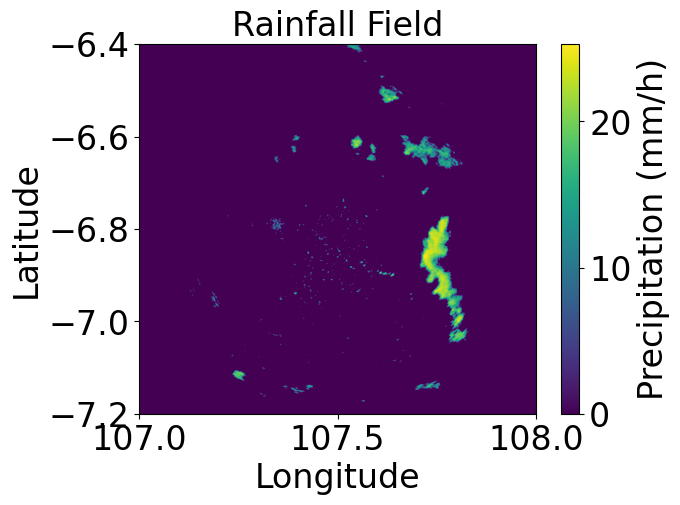

{'accutime': 120,
 'cartesian_map': True,
 'institution': 'Santanu',
 'lat': array([-7.2       , -7.19890859, -7.19781719, -7.19672578, -7.19563438,
       -7.19454297, -7.19345157, -7.19236016, -7.19126876, -7.19017735,
       -7.18908595, -7.18799454, -7.18690314, -7.18581173, -7.18472033,
       -7.18362892, -7.18253752, -7.18144611, -7.18035471, -7.1792633 ,
       -7.1781719 , -7.17708049, -7.17598909, -7.17489768, -7.17380628,
       -7.17271487, -7.17162347, -7.17053206, -7.16944065, -7.16834925,
       -7.16725784, -7.16616644, -7.16507503, -7.16398363, -7.16289222,
       -7.16180082, -7.16070941, -7.15961801, -7.1585266 , -7.1574352 ,
       -7.15634379, -7.15525239, -7.15416098, -7.15306958, -7.15197817,
       -7.15088677, -7.14979536, -7.14870396, -7.14761255, -7.14652115,
       -7.14542974, -7.14433834, -7.14324693, -7.14215553, -7.14106412,
       -7.13997271, -7.13888131, -7.1377899 , -7.1366985 , -7.13560709,
       -7.13451569, -7.13342428, -7.13233288, -7.13124147, 

In [17]:
# Now use the custom plotting function
custom_plot_precip_field(R[-1, :, :], geodata=metadata, title="Rainfall Field")

# Log-transform the data to unit of dBR, set the threshold to 0.1 mm/h,
# set the fill value to -15 dBR
R, metadata = transformation.dB_transform(R, metadata, threshold=0.1, zerovalue=-15.0)

# Set missing values with the fill value
R[~np.isfinite(R)] = -15.0

# Print the metadata
pprint(metadata)

In [18]:
import copy
import warnings

import matplotlib.pylab as plt
import numpy as np
from matplotlib import pyplot, colors

from pysteps.visualization.utils import get_geogrid, get_basemap_axis

PRECIP_VALID_TYPES = ("intensity", "depth", "prob")
PRECIP_VALID_UNITS = ("mm/h", "mm", "dBZ")

def plot_precip_field(
    precip,
    ptype="intensity",
    ax=[106.5, -7.0, 108.0, -6.5],
    geodata=None,
    units="mm/h",
    bbox=None,
    colorscale="pysteps",
    probthr=None,
    title=None,
    colorbar=True,
    axis="Off",
    cax=None,
    map_kwargs=None,
    colormap_config=None,
):

    if map_kwargs is None:
        map_kwargs = {}

    if ptype not in PRECIP_VALID_TYPES:
        raise ValueError(
            f"Invalid precipitation type '{ptype}'."
            f"Supported: {str(PRECIP_VALID_TYPES)}"
        )

    if units not in PRECIP_VALID_UNITS:
        raise ValueError(
            f"Invalid precipitation units '{units}."
            f"Supported: {str(PRECIP_VALID_UNITS)}"
        )

    if ptype == "prob" and colorbar and probthr is None:
        raise ValueError("ptype='prob' but probthr not specified")

    if len(precip.shape) != 2:
        raise ValueError("The input is not two-dimensional array")

    # Assumes the input dimensions are lat/lon
    nlat, nlon = precip.shape

    x_grid, y_grid, extent, regular_grid, origin = get_geogrid(
        nlat, nlon, geodata=geodata
    )

    ax = get_basemap_axis(extent, ax=ax, geodata=geodata, map_kwargs=map_kwargs)

    precip = np.ma.masked_invalid(precip)

    # Handle colormap configuration
    if colormap_config is None:
        cmap, norm, clevs, clevs_str = get_colormap(ptype, units, colorscale)
    else:
        cmap, norm, clevs = _validate_colormap_config(colormap_config, ptype)
        clevs_str = _dynamic_formatting_floats(clevs)

    # Plot the precipitation field
    if regular_grid:
        im = _plot_field(precip, ax, extent, cmap, norm, origin=origin)
    else:
        im = _plot_field(precip, ax, extent, cmap, norm, x_grid=x_grid, y_grid=y_grid)

    plt.title(title)

    # Add colorbar outside the plot
    if colorbar:
        if ptype in ["intensity", "depth"]:
            extend = "max"
        else:
            extend = "neither"
        
        # Adjust the layout to make space for the colorbar
        plt.subplots_adjust(right=0.85)  # Adjust the right margin to make space for the colorbar
        
        # Create a new axis for the colorbar
        cax = plt.axes([0.9, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
        
        cbar = plt.colorbar(
            im, ticks=clevs, spacing="uniform", extend=extend, shrink=0.8, cax=cax
        )
        if clevs_str is not None:
            cbar.ax.set_yticklabels(clevs_str)

        if ptype == "intensity":
            cbar.set_label(f"Precipitation intensity [{units}]")
        elif ptype == "depth":
            cbar.set_label(f"Precipitation depth [{units}]")
        else:
            cbar.set_label(f"P(R > {probthr:.1f} {units})")

    if geodata is None or axis == "off":
        ax.xaxis.set_ticks([])
        ax.xaxis.set_ticklabels([])
        ax.yaxis.set_ticks([])
        ax.yaxis.set_ticklabels([])

    if bbox is not None:
        ax.set_xlim(bbox[0], bbox[2])
        ax.set_ylim(bbox[1], bbox[3])

    return ax


def _plot_field(precip, ax, extent, cmap, norm, origin=None, x_grid=None, y_grid=None):
    precip = precip.copy()

    if (x_grid is None) or (y_grid is None):
        im = ax.imshow(
            precip,
            cmap=cmap,
            norm=norm,
            extent=extent,
            interpolation="nearest",
            origin=origin,
            zorder=10,
        )
    else:
        im = ax.pcolormesh(
            x_grid,
            y_grid,
            precip,
            cmap=cmap,
            norm=norm,
            zorder=10,
        )

    return im


def get_colormap(ptype, units="mm/h", colorscale="pysteps"):
    
    if ptype in ["intensity", "depth"]:
        # Get list of colors
        color_list, clevs, clevs_str = _get_colorlist(units, colorscale)

        cmap = colors.LinearSegmentedColormap.from_list(
            "cmap", color_list, len(clevs) - 1
        )

        if colorscale == "BOM-RF3":
            cmap.set_over("black", 1)
        if colorscale == "pysteps":
            cmap.set_over("darkred", 1)
        if colorscale == "STEPS-NL":
            cmap.set_over("darkmagenta", 1)
        if colorscale == "STEPS-BE":
            cmap.set_over("black", 1)
        norm = colors.BoundaryNorm(clevs, cmap.N)

        cmap.set_bad("gray", alpha=0.5)
        cmap.set_under("none")

        return cmap, norm, clevs, clevs_str

    if ptype == "prob":
        cmap = copy.copy(plt.get_cmap("OrRd", 10))
        cmap.set_bad("gray", alpha=0.5)
        cmap.set_under("none")
        clevs = np.linspace(0, 1, 11)
        clevs[0] = 1e-3  # to set zeros to transparent
        norm = colors.BoundaryNorm(clevs, cmap.N)
        clevs_str = [f"{clev:.1f}" for clev in clevs]
        return cmap, norm, clevs, clevs_str

    return pyplot.get_cmap("jet"), colors.Normalize(), None, None


def _get_colorlist(units="mm/h", colorscale="pysteps"):

    if colorscale == "BOM-RF3":
        color_list = np.array(
            [
                (255, 255, 255),  # 0.0
                (245, 245, 255),  # 0.2
                (180, 180, 255),  # 0.5
                (120, 120, 255),  # 1.5
                (20, 20, 255),  # 2.5
                (0, 216, 195),  # 4.0
                (0, 150, 144),  # 6.0
                (0, 102, 102),  # 10
                (255, 255, 0),  # 15
                (255, 200, 0),  # 20
                (255, 150, 0),  # 30
                (255, 100, 0),  # 40
                (255, 0, 0),  # 50
                (200, 0, 0),  # 60
                (120, 0, 0),  # 75
                (40, 0, 0),
            ]
        )  # > 100
        color_list = color_list / 255.0
        if units == "mm/h":
            clevs = [
                0.0,
                0.2,
                0.5,
                1.5,
                2.5,
                4,
                6,
                10,
                15,
                20,
                30,
                40,
                50,
                60,
                75,
                100,
                150,
            ]
        elif units == "mm":
            clevs = [
                0.0,
                0.2,
                0.5,
                1.5,
                2.5,
                4,
                5,
                7,
                10,
                15,
                20,
                25,
                30,
                35,
                40,
                45,
                50,
            ]
        else:
            raise ValueError("Wrong units in get_colorlist: %s" % units)
    elif colorscale == "pysteps":
        # pinkHex = '#%02x%02x%02x' % (232, 215, 242)
        redgrey_hex = "#%02x%02x%02x" % (156, 126, 148)
        color_list = [
            redgrey_hex,
            "#640064",
            "#AF00AF",
            "#DC00DC",
            "#3232C8",
            "#0064FF",
            "#009696",
            "#00C832",
            "#64FF00",
            "#96FF00",
            "#C8FF00",
            "#FFFF00",
            "#FFC800",
            "#FFA000",
            "#FF7D00",
            "#E11900",
        ]
        if units in ["mm/h", "mm"]:
            clevs = [
                0.08,
                0.16,
                0.25,
                0.40,
                0.63,
                1,
                1.6,
                2.5,
                4,
                6.3,
                10,
                16,
                25,
                40,
                63,
                100,
                160,
            ]
        elif units == "dBZ":
            clevs = np.arange(10, 65, 5)
        else:
            raise ValueError("Wrong units in get_colorlist: %s" % units)
    elif colorscale == "STEPS-NL":
        redgrey_hex = "#%02x%02x%02x" % (156, 126, 148)
        color_list = [
            "lightgrey",
            "lightskyblue",
            "deepskyblue",
            "blue",
            "darkblue",
            "yellow",
            "gold",
            "darkorange",
            "red",
            "darkred",
        ]
        if units in ["mm/h", "mm"]:
            clevs = [0.1, 0.5, 1.0, 1.6, 2.5, 4.0, 6.4, 10.0, 16.0, 25.0, 40.0]
        else:
            raise ValueError("Wrong units in get_colorlist: %s" % units)
    elif colorscale == "STEPS-BE":
        color_list = [
            "cyan",
            "deepskyblue",
            "dodgerblue",
            "blue",
            "chartreuse",
            "limegreen",
            "green",
            "darkgreen",
            "yellow",
            "gold",
            "orange",
            "red",
            "magenta",
            "darkmagenta",
        ]
        if units in ["mm/h", "mm"]:
            clevs = [0.1, 0.25, 0.4, 0.63, 1, 1.6, 2.5, 4, 6.3, 10, 16, 25, 40, 63, 100]
        elif units == "dBZ":
            clevs = np.arange(10, 65, 5)
        else:
            raise ValueError("Wrong units in get_colorlist: %s" % units)

    else:
        print("Invalid colorscale", colorscale)
        raise ValueError("Invalid colorscale " + colorscale)

    # Generate color level strings with correct amount of decimal places
    clevs_str = _dynamic_formatting_floats(clevs)

    return color_list, clevs, clevs_str


def _dynamic_formatting_floats(float_array, colorscale="pysteps"):
    """Function to format the floats defining the class limits of the colorbar."""
    float_array = np.array(float_array, dtype=float)

    labels = []
    for label in float_array:
        if 0.1 <= label < 1:
            if colorscale == "pysteps":
                formatting = ",.2f"
            else:
                formatting = ",.1f"
        elif 0.01 <= label < 0.1:
            formatting = ",.2f"
        elif 0.001 <= label < 0.01:
            formatting = ",.3f"
        elif 0.0001 <= label < 0.001:
            formatting = ",.4f"
        elif label >= 1 and label.is_integer():
            formatting = "i"
        else:
            formatting = ",.1f"

        if formatting != "i":
            labels.append(format(label, formatting))
        else:
            labels.append(str(int(label)))

    return labels


def _validate_colormap_config(colormap_config, ptype):
    """Validate the colormap configuration provided by the user."""

    # Ensure colormap_config has the necessary attributes
    required_attrs = ["cmap", "norm", "clevs"]
    missing_attrs = [
        attr for attr in required_attrs if not hasattr(colormap_config, attr)
    ]
    if missing_attrs:
        raise ValueError(
            f"colormap_config is missing required attributes: {', '.join(missing_attrs)}"
        )

    # Ensure that ptype is appropriate when colormap_config is provided
    if ptype not in ["intensity", "depth"]:
        raise ValueError(
            "colormap_config is only supported for ptype='intensity' or 'depth'"
        )

    cmap = colormap_config.cmap
    clevs = colormap_config.clevs

    # Validate that the number of colors matches len(clevs)
    if isinstance(cmap, colors.ListedColormap):
        num_colors = len(cmap.colors)
    else:
        num_colors = cmap.N

    expected_colors = len(clevs)
    if num_colors != expected_colors:
        raise ValueError(
            f"Number of colors in colormap (N={num_colors}) does not match len(clevs) (N={expected_colors})."
        )

    return colormap_config.cmap, colormap_config.norm, colormap_config.clevs


In [19]:
# Add this function definition at the beginning of your script (with other imports)
def create_consistent_colormap(units="mm/h"):
    """Create a consistent colormap for both observed and nowcast plots"""
    if units in ["mm/h", "mm"]:
        clevs = [0.08, 0.16, 0.25, 0.40, 0.63, 1, 1.6, 2.5, 4, 6.3, 10, 16, 25, 40, 63, 100, 160]
        color_list = [
            '#9c7e94', '#640064', '#AF00AF', '#DC00DC', '#3232C8',
            '#0064FF', '#009696', '#00C832', '#64FF00', '#96FF00',
            '#C8FF00', '#FFFF00', '#FFC800', '#FFA000', '#FF7D00', '#E11900'
        ]
    else:
        clevs = np.arange(10, 65, 5)
        color_list = plt.cm.jet(np.linspace(0, 1, len(clevs)))
    
    cmap = colors.LinearSegmentedColormap.from_list("consistent_cmap", color_list, len(clevs)-1)
    cmap.set_over("darkred", 1)
    cmap.set_bad("gray", alpha=0.5)
    cmap.set_under("none")
    norm = colors.BoundaryNorm(clevs, cmap.N)
    
    return cmap, norm, clevs


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pysteps import nowcasts
from pysteps.motion.lucaskanade import dense_lucaskanade
from pysteps.utils import transformation
import os
import matplotlib as mpl
from matplotlib import colors
import cartopy.crs as crs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import scipy.io

# Set font sizes
mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Set nowcast parameters
n_ens_members = 10
seed = 24

# Data source configuration
date_str = "20221109" 
date = datetime.strptime(date_str, "%Y%m%d")
root_path = "D:/College/MENEA/FIXED_DATA/RUN_TEST/"
output_directory = r"D:/College/MENEA/FIXED_DATA/OUTPUT/20221109/nowcasts/"
os.makedirs(output_directory, exist_ok=True)

def load_santanu_data(date, root_path):
    """Load radar reflectivity data from .mat files"""
    date_folder = os.path.join(root_path, date.strftime("%Y%m%d"))
    if not os.path.exists(date_folder):
        raise FileNotFoundError(f"Folder {date_folder} does not exist.")
    
    R = []
    times = []
    
    for filename in os.listdir(date_folder):
        if filename.endswith('.mat'):
            file_path = os.path.join(date_folder, filename)
            mat_data = scipy.io.loadmat(file_path)
            
            if 'ZI' not in mat_data:
                continue
            
            reflectivity = mat_data['ZI'] / 10000
            reflectivity[reflectivity == -1] = np.nan
            R.append(reflectivity)
            
            if 'f' in mat_data and 't' in mat_data:
                time_str = mat_data['f'][0][0]
                times.append(int(time_str))
    
    if not R:
        raise ValueError("No valid reflectivity data found.")
    
    metadata = {
        "institution": "Santanu",
        "accutime": 120,
        "unit": "mm/h",
        "transform": "dB",
        "zerovalue": 0,
        "threshold": 0.1,
        'x1': 107, 'x2': 108,
        'y1': -7.1, 'y2': -6.4,
        'lat': np.linspace(-7.1, -6.4, R[0].shape[0]),
        'lon': np.linspace(107, 108, R[0].shape[1]),
        'regular_grid': True,
        'projection': "+proj=merc +lon_0=0 +datum=WGS84 +units=m +no_defs",
        'yorigin': 'upper',
        'xorigin': '',
        'cartesian_map': True,
        'zr_a': 316.0,
        'zr_b': 1.5,
    }
    return np.array(R), np.array(times), metadata

def create_precip_colormap():
    """Create precipitation colormap using pysteps style"""
    clevs = [0.08,0.16,0.25,0.40,0.63,1,1.6,2.5,4,6.3,10,16,25,40,63,100,160]
    color_list = [
        '#9c7e94','#640064','#AF00AF','#DC00DC','#3232C8',
        '#0064FF','#009696','#00C832','#64FF00','#96FF00',
        '#C8FF00','#FFFF00','#FFC800','#FFA000','#FF7D00','#E11900'
    ]
    
    cmap = colors.LinearSegmentedColormap.from_list(
        "pysteps_precip", color_list, len(clevs)-1)
    cmap.set_over("darkred",1)
    cmap.set_bad("gray",alpha=0.5)
    cmap.set_under("none")
    norm = colors.BoundaryNorm(clevs, cmap.N)
    
    return cmap, norm, clevs

# Main processing
def generate_nowcast_subplots():
    # Load and prepare data
    R, times, metadata = load_santanu_data(date, root_path)
    R, metadata = transformation.dB_transform(
        R, metadata, threshold=0.1, zerovalue=-15.0)
    R[~np.isfinite(R)] = -15.0
    
    # Estimate motion field
    V = dense_lucaskanade(R)
    
    # Create colormap
    cmap, norm, clevs = create_precip_colormap()
    
    # Define lead times (minutes)
    lead_times = [10, 20, 30, 40, 50, 60]
    
    # Create figure with adjusted layout
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle('Precipitation Nowcast Ensemble Mean', fontsize=16, y=1.02)
    
    # Adjust subplot spacing
    plt.subplots_adjust(left=0.05, right=0.95, bottom=0.12, top=0.9, 
                       wspace=0.15, hspace=0.25)
    
    # Create subplots
    axs = []
    for i in range(6):
        ax = fig.add_subplot(2, 3, i+1, projection=crs.PlateCarree())
        axs.append(ax)
    
    # Generate and plot nowcasts
    for i, lead_time_min in enumerate(lead_times):
        n_leadtimes = int(lead_time_min / (metadata["accutime"] / 60))
        
        # Generate nowcast (using parameters from Script 1)
        R_f_steps = nowcasts.get_method("steps")(
            R[-3:, :, :], 
            V, 
            n_leadtimes,
            n_ens_members,
            n_cascade_levels=6,
            precip_thr=10,  # Using threshold from Script 1
            kmperpixel=2.0,
            timestep=metadata["accutime"]/60,
            noise_method="nonparametric",
            vel_pert_method="bps",
            mask_method="incremental",
            seed=seed
        )
        
        # Back-transform to rain rates (using threshold from Script 1)
        R_f_steps = transformation.dB_transform(
            R_f_steps, threshold=10.0, inverse=True)[0]
        R_f_steps[~np.isfinite(R_f_steps)] = 0
        R_f_mean = np.mean(R_f_steps[:, -1, :, :], axis=0)
        
        # Plot precipitation field with style from Script 1
        im = axs[i].imshow(
            R_f_mean,
            extent=[metadata['x1'], metadata['x2'], metadata['y1'], metadata['y2']],
            cmap=cmap,
            norm=norm,
            transform=crs.PlateCarree(),
            origin='upper',
            aspect='auto')  # From Script 1
        
        # Configure gridlines from Script 2
        gl = axs[i].gridlines(
            draw_labels=True, 
            linestyle='--', 
            alpha=0.5, 
            linewidth=1)
        gl.xlocator = plt.FixedLocator([107.2, 107.4, 107.6, 107.8, 108.0])
        gl.ylocator = plt.FixedLocator([-7.0, -6.8, -6.6])
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        
        # Only show labels for left and bottom plots
        if i not in [0, 3]:
            gl.left_labels = False
        if i < 3:
            gl.bottom_labels = False
        
        # Title format from Script 1
        axs[i].set_title(f"Ensemble mean (+{lead_time_min} min)", fontsize=14, pad=10)
        axs[i].set_xlim(107, 108)
        axs[i].set_ylim(-7.1, -6.4)
        axs[i].coastlines(resolution='10m', color='black', linewidth=0.5)
    
    # Add colorbar with style from Script 1
    cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='max')
    cbar.set_label('Precipitation intensity [mm/h]', fontsize=14)
    cbar.ax.tick_params(labelsize=32)
    
    # Save figure
    output_path = os.path.join(output_directory, "nowcast_subplots_combined.png")
    plt.savefig(output_path, bbox_inches='tight', dpi=300, facecolor='white')
    print(f"Figure successfully saved to: {output_path}")
    plt.close()

if __name__ == "__main__":
    generate_nowcast_subplots()

Computing STEPS nowcast
-----------------------

Inputs
------
input dimensions: 734x734
km/pixel:         2.0
time step:        2.0 minutes

Methods
-------
extrapolation:          semilagrangian
bandpass filter:        gaussian
decomposition:          fft
noise generator:        nonparametric
noise adjustment:       no
velocity perturbator:   bps
conditional statistics: no
precip. mask method:    incremental
probability matching:   cdf
FFT method:             numpy
domain:                 spatial

Parameters
----------
number of time steps:     5
ensemble size:            10
parallel threads:         1
number of cascade levels: 6
order of the AR(p) model: 2
velocity perturbations, parallel:      10.88,0.23,-7.68
velocity perturbations, perpendicular: 5.76,0.31,-2.72
precip. intensity threshold: 10
************************************************
* Correlation coefficients for cascade levels: *
************************************************
-----------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pysteps import nowcasts
from pysteps.motion.lucaskanade import dense_lucaskanade
from pysteps.utils import transformation
import os
import matplotlib as mpl
from matplotlib import colors
import cartopy.crs as crs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import scipy.io

# Set font sizes
mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Set nowcast parameters
n_ens_members = 10
seed = 24

# Data source configuration
date_str = "20221109" 
date = datetime.strptime(date_str, "%Y%m%d")
root_path = "D:/College/MENEA/FIXED_DATA/RUN_TEST/"
output_directory = r"D:/College/MENEA/FIXED_DATA/OUTPUT/20221109/nowcasts/"
os.makedirs(output_directory, exist_ok=True)

def load_santanu_data(date, root_path):
    """Load radar reflectivity data from .mat files"""
    date_folder = os.path.join(root_path, date.strftime("%Y%m%d"))
    if not os.path.exists(date_folder):
        raise FileNotFoundError(f"Folder {date_folder} does not exist.")
    
    R = []
    times = []
    
    for filename in os.listdir(date_folder):
        if filename.endswith('.mat'):
            file_path = os.path.join(date_folder, filename)
            mat_data = scipy.io.loadmat(file_path)
            
            if 'ZI' not in mat_data:
                continue
            
            reflectivity = mat_data['ZI'] / 10000
            reflectivity[reflectivity == -1] = np.nan
            R.append(reflectivity)
            
            if 'f' in mat_data and 't' in mat_data:
                time_str = mat_data['f'][0][0]
                times.append(int(time_str))
    
    if not R:
        raise ValueError("No valid reflectivity data found.")
    
    metadata = {
        "institution": "Santanu",
        "accutime": 120,
        "unit": "mm/h",
        "transform": "dB",
        "zerovalue": 0,
        "threshold": 0.1,
        'x1': 107, 'x2': 108,
        'y1': -7.1, 'y2': -6.4,
        'lat': np.linspace(-7.1, -6.4, R[0].shape[0]),
        'lon': np.linspace(107, 108, R[0].shape[1]),
        'regular_grid': True,
        'projection': "+proj=merc +lon_0=0 +datum=WGS84 +units=m +no_defs",
        'yorigin': 'upper',
        'xorigin': '',
        'cartesian_map': True,
        'zr_a': 316.0,
        'zr_b': 1.5,
    }
    return np.array(R), np.array(times), metadata

def create_precip_colormap():
    """Create precipitation colormap using pysteps style"""
    clevs = [0.08,0.16,0.25,0.40,0.63,1,1.6,2.5,4,6.3,10,16,25,40,63,100,160]
    color_list = [
        '#9c7e94','#640064','#AF00AF','#DC00DC','#3232C8',
        '#0064FF','#009696','#00C832','#64FF00','#96FF00',
        '#C8FF00','#FFFF00','#FFC800','#FFA000','#FF7D00','#E11900'
    ]
    
    cmap = colors.LinearSegmentedColormap.from_list(
        "pysteps_precip", color_list, len(clevs)-1)
    cmap.set_over("darkred",1)
    cmap.set_bad("gray",alpha=0.5)
    cmap.set_under("none")
    norm = colors.BoundaryNorm(clevs, cmap.N)
    
    return cmap, norm, clevs

# Main processing
def generate_nowcast_subplots():
    # Load and prepare data
    R, times, metadata = load_santanu_data(date, root_path)
    R, metadata = transformation.dB_transform(
        R, metadata, threshold=0.1, zerovalue=-15.0)
    R[~np.isfinite(R)] = -15.0
    
    # Estimate motion field
    V = dense_lucaskanade(R)
    
    # Create colormap
    cmap, norm, clevs = create_precip_colormap()
    
    # Define lead times (minutes)
    lead_times = [10, 20, 30, 40, 50, 60]
    
    # Create figure with adjusted layout
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle('Precipitation Nowcast Ensemble Mean', fontsize=16, y=1.02)
    
    # Adjust subplot spacing
    plt.subplots_adjust(left=0.05, right=0.95, bottom=0.12, top=0.9, 
                       wspace=0.15, hspace=0.25)
    
    # Create subplots
    axs = []
    for i in range(6):
        ax = fig.add_subplot(2, 3, i+1, projection=crs.PlateCarree())
        axs.append(ax)
    
    # Generate and plot nowcasts
    for i, lead_time_min in enumerate(lead_times):
        n_leadtimes = int(lead_time_min / (metadata["accutime"] / 60))
        
        # Generate nowcast (using parameters from Script 1)
        R_f_steps = nowcasts.get_method("steps")(
            R[-3:, :, :], 
            V, 
            n_leadtimes,
            n_ens_members,
            n_cascade_levels=6,
            precip_thr=10,  # Using threshold from Script 1
            kmperpixel=2.0,
            timestep=metadata["accutime"]/60,
            noise_method="nonparametric",
            vel_pert_method="bps",
            mask_method="incremental",
            seed=seed
        )
        
        # Back-transform to rain rates (using threshold from Script 1)
        R_f_steps = transformation.dB_transform(
            R_f_steps, threshold=10.0, inverse=True)[0]
        R_f_steps[~np.isfinite(R_f_steps)] = 0
        R_f_mean = np.mean(R_f_steps[:, -1, :, :], axis=0)
        
        # Plot precipitation field with style from Script 1
        im = axs[i].imshow(
            R_f_mean,
            extent=[metadata['x1'], metadata['x2'], metadata['y1'], metadata['y2']],
            cmap=cmap,
            norm=norm,
            transform=crs.PlateCarree(),
            origin='upper',
            aspect='auto')  # From Script 1
        
         # Configure gridlines
        gl = axs[i].gridlines(
            draw_labels=True, 
            linestyle='--', 
            alpha=0.5, 
            linewidth=1)
        gl.xlocator = plt.FixedLocator([107.2, 107.4, 107.6, 107.8, 108.0])
        gl.ylocator = plt.FixedLocator([-7.0, -6.8, -6.6])
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        
        # Set font size for all tick labels
        gl.xlabel_style = {'size': 24}
        gl.ylabel_style = {'size': 24}
        
        # Show x labels at bottom for all subplots
        gl.bottom_labels = True
        gl.top_labels = False
            
        # Only show y labels for left column (subplots 1 and 4)
        if i not in [0, 3]:  # Not left column
            gl.left_labels = False
            gl.right_labels = False
        else:                # Left column
            gl.right_labels = False

        # Title format from Script 1
        axs[i].set_title(f"Ensemble mean (+{lead_time_min} min)", fontsize=14, pad=10)
        axs[i].set_xlim(107, 108)
        axs[i].set_ylim(-7.1, -6.4)
        axs[i].coastlines(resolution='10m', color='black', linewidth=0.5)
    
    # Add colorbar with style from Script 1
    cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='max')
    cbar.set_label('Precipitation intensity [mm/h]', fontsize=14)
    cbar.ax.tick_params(labelsize=18)
    
    # Save figure
    output_path = os.path.join(output_directory, "nowcast_subplots_combined.png")
    plt.savefig(output_path, bbox_inches='tight', dpi=300, facecolor='white')
    print(f"Figure successfully saved to: {output_path}")
    plt.close()

if __name__ == "__main__":
    generate_nowcast_subplots()

Pysteps configuration file found at: c:\Users\LENOVO\anaconda3\envs\vyrginia\Lib\site-packages\pysteps\pystepsrc

Computing STEPS nowcast
-----------------------

Inputs
------
input dimensions: 734x734
km/pixel:         2.0
time step:        2.0 minutes

Methods
-------
extrapolation:          semilagrangian
bandpass filter:        gaussian
decomposition:          fft
noise generator:        nonparametric
noise adjustment:       no
velocity perturbator:   bps
conditional statistics: no
precip. mask method:    incremental
probability matching:   cdf
FFT method:             numpy
domain:                 spatial

Parameters
----------
number of time steps:     5
ensemble size:            10
parallel threads:         1
number of cascade levels: 6
order of the AR(p) model: 2
velocity perturbations, parallel:      10.88,0.23,-7.68
velocity perturbations, perpendicular: 5.76,0.31,-2.72
precip. intensity threshold: 10
************************************************
* Correlation coefficients

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pysteps import nowcasts
from pysteps.motion.lucaskanade import dense_lucaskanade
from pysteps.utils import transformation
import os
import matplotlib as mpl
from matplotlib import colors
import cartopy.crs as crs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import scipy.io

# Set font sizes
mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Set nowcast parameters
n_ens_members = 10
seed = 24

# Data source configuration
date_str = "20221109" 
date = datetime.strptime(date_str, "%Y%m%d")
root_path = "D:/College/MENEA/FIXED_DATA/RUN_TEST/"
output_directory = r"D:/College/MENEA/FIXED_DATA/OUTPUT/20221109/nowcasts/"
os.makedirs(output_directory, exist_ok=True)

def load_santanu_data(date, root_path):
    """Load radar reflectivity data from .mat files"""
    date_folder = os.path.join(root_path, date.strftime("%Y%m%d"))
    if not os.path.exists(date_folder):
        raise FileNotFoundError(f"Folder {date_folder} does not exist.")
    
    R = []
    times = []
    
    for filename in os.listdir(date_folder):
        if filename.endswith('.mat'):
            file_path = os.path.join(date_folder, filename)
            mat_data = scipy.io.loadmat(file_path)
            
            if 'ZI' not in mat_data:
                continue
            
            reflectivity = mat_data['ZI'] / 10000
            reflectivity[reflectivity == -1] = np.nan
            R.append(reflectivity)
            
            if 'f' in mat_data and 't' in mat_data:
                time_str = mat_data['f'][0][0]
                times.append(int(time_str))
    
    if not R:
        raise ValueError("No valid reflectivity data found.")
    
    metadata = {
        "institution": "Santanu",
        "accutime": 120,
        "unit": "mm/h",
        "transform": "dB",
        "zerovalue": 0,
        "threshold": 0.1,
        'x1': 107, 'x2': 108,
        'y1': -7.1, 'y2': -6.4,
        'lat': np.linspace(-7.1, -6.4, R[0].shape[0]),
        'lon': np.linspace(107, 108, R[0].shape[1]),
        'regular_grid': True,
        'projection': "+proj=merc +lon_0=0 +datum=WGS84 +units=m +no_defs",
        'yorigin': 'upper',
        'xorigin': '',
        'cartesian_map': True,
        'zr_a': 316.0,
        'zr_b': 1.5,
    }
    return np.array(R), np.array(times), metadata

def create_precip_colormap():
    """Create precipitation colormap using pysteps style"""
    clevs = [0.08,0.16,0.25,0.40,0.63,1,1.6,2.5,4,6.3,10,16,25,40,63,100,160]
    color_list = [
        '#9c7e94','#640064','#AF00AF','#DC00DC','#3232C8',
        '#0064FF','#009696','#00C832','#64FF00','#96FF00',
        '#C8FF00','#FFFF00','#FFC800','#FFA000','#FF7D00','#E11900'
    ]
    
    cmap = colors.LinearSegmentedColormap.from_list(
        "pysteps_precip", color_list, len(clevs)-1)
    cmap.set_over("darkred",1)
    cmap.set_bad("gray",alpha=0.5)
    cmap.set_under("none")
    norm = colors.BoundaryNorm(clevs, cmap.N)
    
    return cmap, norm, clevs

def generate_nowcast_subplots():
    # Load and prepare data
    R, times, metadata = load_santanu_data(date, root_path)
    R, metadata = transformation.dB_transform(
        R, metadata, threshold=0.1, zerovalue=-15.0)
    R[~np.isfinite(R)] = -15.0
    
    # Estimate motion field
    V = dense_lucaskanade(R)
    
    # Create colormap
    cmap, norm, clevs = create_precip_colormap()
    
    # Define lead times (minutes)
    lead_times = [10, 20, 30, 40, 50, 60]
    
    # Create figure with adjusted layout
    fig = plt.figure(figsize=(22, 14))
    fig.suptitle('Precipitation Nowcast Ensemble Mean', fontsize=16, y=0.95)
    
    # Adjust subplot spacing with more generous margins
    plt.subplots_adjust(
        left=0.08,
        right=0.92,
        bottom=0.18,
        top=0.88,
        wspace=0.3,
        hspace=0.4
    )
    
    # Create subplots
    axs = []
    for i in range(6):
        ax = fig.add_subplot(2, 3, i+1, projection=crs.PlateCarree())
        axs.append(ax)
    
    # Generate and plot nowcasts
    for i, lead_time_min in enumerate(lead_times):
        n_leadtimes = int(lead_time_min / (metadata["accutime"] / 60))
        
        # Generate nowcast
        R_f_steps = nowcasts.get_method("steps")(
            R[-3:, :, :], 
            V, 
            n_leadtimes,
            n_ens_members,
            n_cascade_levels=6,
            precip_thr=10,
            kmperpixel=2.0,
            timestep=metadata["accutime"]/60,
            noise_method="nonparametric",
            vel_pert_method="bps",
            mask_method="incremental",
            seed=seed
        )
        
        # Back-transform to rain rates
        R_f_steps = transformation.dB_transform(
            R_f_steps, threshold=10.0, inverse=True)[0]
        R_f_steps[~np.isfinite(R_f_steps)] = 0
        R_f_mean = np.mean(R_f_steps[:, -1, :, :], axis=0)
        
        # Plot precipitation field
        im = axs[i].imshow(
            R_f_mean,
            extent=[metadata['x1'], metadata['x2'], metadata['y1'], metadata['y2']],
            cmap=cmap,
            norm=norm,
            transform=crs.PlateCarree(),
            origin='upper',
            aspect='auto')
        
        # Configure gridlines with optimal spacing
        gl = axs[i].gridlines(
            draw_labels=True,
            linestyle='--',
            alpha=0.5,
            linewidth=1,
            color='gray')
        
        # Set fixed longitude and latitude ticks
        gl.xlocator = plt.FixedLocator([107.0, 107.2, 107.4, 107.6, 107.8, 108.0])
        gl.ylocator = plt.FixedLocator([-7.0, -6.8, -6.6])
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        
        # Set label styles without padding parameter
        gl.xlabel_style = {'size': 20}
        gl.ylabel_style = {'size': 20}
        
        # Standardize label positions
        gl.left_labels = True
        gl.bottom_labels = True
        gl.right_labels = False
        gl.top_labels = False
        
        # Adjust title and ticks
        axs[i].set_title(f"Ensemble mean (+{lead_time_min} min)", fontsize=14, pad=15)
        axs[i].set_xlim(107, 108)
        axs[i].set_ylim(-7.1, -6.4)
        axs[i].tick_params(axis='both', which='major', pad=8)
        axs[i].coastlines(resolution='10m', color='black', linewidth=0.8)
    
    # Add colorbar with adjusted position
    cbar_ax = fig.add_axes([0.3, 0.12, 0.4, 0.02])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='max')
    cbar.set_label('Precipitation intensity [mm/h]', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    
    # Save figure
    output_path = os.path.join(output_directory, "nowcast_subplots_optimized.png")
    plt.savefig(output_path, bbox_inches='tight', dpi=300, facecolor='white')
    print(f"Figure successfully saved to: {output_path}")
    plt.close()

if __name__ == "__main__":
    generate_nowcast_subplots()

Computing STEPS nowcast
-----------------------

Inputs
------
input dimensions: 734x734
km/pixel:         2.0
time step:        2.0 minutes

Methods
-------
extrapolation:          semilagrangian
bandpass filter:        gaussian
decomposition:          fft
noise generator:        nonparametric
noise adjustment:       no
velocity perturbator:   bps
conditional statistics: no
precip. mask method:    incremental
probability matching:   cdf
FFT method:             numpy
domain:                 spatial

Parameters
----------
number of time steps:     5
ensemble size:            10
parallel threads:         1
number of cascade levels: 6
order of the AR(p) model: 2
velocity perturbations, parallel:      10.88,0.23,-7.68
velocity perturbations, perpendicular: 5.76,0.31,-2.72
precip. intensity threshold: 10
************************************************
* Correlation coefficients for cascade levels: *
************************************************
-----------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pysteps import nowcasts
from pysteps.motion.lucaskanade import dense_lucaskanade
from pysteps.utils import transformation
import os
import matplotlib as mpl
from matplotlib import colors
import cartopy.crs as crs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import scipy.io

# Set font sizes to match Script 2 exactly
mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# Set nowcast parameters
n_ens_members = 10
seed = 24

# Data source configuration
date_str = "20221109" 
date = datetime.strptime(date_str, "%Y%m%d")
root_path = "D:/College/MENEA/FIXED_DATA/RUN_TEST/"
output_directory = r"D:/College/MENEA/FIXED_DATA/OUTPUT/20221109/nowcasts/"
os.makedirs(output_directory, exist_ok=True)

def load_santanu_data(date, root_path):
    """Load radar reflectivity data from .mat files"""
    date_folder = os.path.join(root_path, date.strftime("%Y%m%d"))
    if not os.path.exists(date_folder):
        raise FileNotFoundError(f"Folder {date_folder} does not exist.")
    
    R = []
    times = []
    
    for filename in sorted(os.listdir(date_folder)):  # Changed to sorted to match Script 2
        if filename.endswith('.mat'):
            file_path = os.path.join(date_folder, filename)
            mat_data = scipy.io.loadmat(file_path)
            
            if 'ZI' not in mat_data:
                continue
            
            reflectivity = mat_data['ZI'] / 10000
            reflectivity[reflectivity == -1] = np.nan
            R.append(reflectivity)
            
            # Extract time matching Script 2's method
            if '_' in filename:
                time_part = filename.split('_')[-1].replace('.mat', '')
                if len(time_part) == 6 and time_part.isdigit():
                    times.append(f"{time_part[:2]}:{time_part[2:4]}")
    
    if not R:
        raise ValueError("No valid reflectivity data found.")
    
    metadata = {
        "institution": "Santanu",
        "accutime": 120,
        "unit": "mm/h",
        "transform": "dB",
        "zerovalue": 0,
        "threshold": 0.1,
        'x1': 107, 'x2': 108,
        'y1': -7.1, 'y2': -6.4,
        'lat': np.linspace(-7.1, -6.4, R[0].shape[0]),
        'lon': np.linspace(107, 108, R[0].shape[1]),
        'regular_grid': True,
        'projection': "+proj=merc +lon_0=0 +datum=WGS84 +units=m +no_defs",
        'yorigin': 'upper',
        'xorigin': '',
        'cartesian_map': True,
        'zr_a': 316.0,
        'zr_b': 1.5,
    }
    return np.array(R), np.array(times), metadata

def create_precip_colormap():
    """Create precipitation colormap using pysteps style (same as both scripts)"""
    clevs = [0.08,0.16,0.25,0.40,0.63,1,1.6,2.5,4,6.3,10,16,25,40,63,100,160]
    color_list = [
        '#9c7e94','#640064','#AF00AF','#DC00DC','#3232C8',
        '#0064FF','#009696','#00C832','#64FF00','#96FF00',
        '#C8FF00','#FFFF00','#FFC800','#FFA000','#FF7D00','#E11900'
    ]
    
    cmap = colors.LinearSegmentedColormap.from_list(
        "pysteps_precip", color_list, len(clevs)-1)
    cmap.set_over("darkred",1)
    cmap.set_bad("gray",alpha=0.5)
    cmap.set_under("none")
    norm = colors.BoundaryNorm(clevs, cmap.N)
    
    return cmap, norm, clevs

def generate_nowcast_subplots_script2_style():
    # Load and prepare data (same as Script 1)
    R, times, metadata = load_santanu_data(date, root_path)
    R, metadata = transformation.dB_transform(
        R, metadata, threshold=0.1, zerovalue=-15.0)
    R[~np.isfinite(R)] = -15.0
    
    # Estimate motion field (same as Script 1)
    V = dense_lucaskanade(R)
    
    # Create colormap (same as both scripts)
    cmap, norm, clevs = create_precip_colormap()
    
    # Define lead times (minutes) - same as Script 1
    lead_times = [10, 20, 30, 40, 50, 60]
    
    # Create figure with Script 2's dimensions
    fig = plt.figure(figsize=(26, 16))
    
    # Adjust subplot spacing to match Script 2 exactly
    plt.subplots_adjust(
        left=0.05, right=0.95, 
        bottom=0.12, top=0.9,
        wspace=0.15, hspace=0.25
    )
    
    # Create subplots
    axs = []
    for i in range(6):
        ax = fig.add_subplot(2, 3, i+1, projection=crs.PlateCarree())
        axs.append(ax)
    
    # Generate and plot nowcasts (same process as Script 1)
    for i, lead_time_min in enumerate(lead_times):
        n_leadtimes = int(lead_time_min / (metadata["accutime"] / 60))
        
        # Generate nowcast (same as Script 1)
        R_f_steps = nowcasts.get_method("steps")(
            R[-3:, :, :], 
            V, 
            n_leadtimes,
            n_ens_members,
            n_cascade_levels=6,
            precip_thr=10,
            kmperpixel=2.0,
            timestep=metadata["accutime"]/60,
            noise_method="nonparametric",
            vel_pert_method="bps",
            mask_method="incremental",
            seed=seed
        )
        
        # Back-transform to rain rates (same as Script 1)
        R_f_steps = transformation.dB_transform(
            R_f_steps, threshold=10.0, inverse=True)[0]
        R_f_steps[~np.isfinite(R_f_steps)] = 0
        R_f_mean = np.mean(R_f_steps[:, -1, :, :], axis=0)
        
        # Plot precipitation field with Script 2's style
        im = axs[i].imshow(
            R_f_mean,
            extent=[metadata['x1'], metadata['x2'], metadata['y1'], metadata['y2']],
            cmap=cmap,
            norm=norm,
            transform=crs.PlateCarree(),
            origin='upper',
            aspect='auto')
        
        # Configure gridlines to match Script 2 exactly
        gl = axs[i].gridlines(
            draw_labels=True,
            linestyle='--',
            alpha=0.5,
            linewidth=1.0)
        
        # Set ticks to match Script 2
        gl.xlocator = plt.FixedLocator([107.2, 107.4, 107.6, 107.8, 108.0])
        gl.ylocator = plt.FixedLocator([-7.0, -6.8, -6.6])
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        
        # Set label styles to match Script 2
        gl.xlabel_style = {'size': 24, 'weight': 'bold'}  # Longitude labels
        gl.ylabel_style = {'size': 24, 'weight': 'bold'}  # Latitude labels
        
        # Label positioning to match Script 2 exactly:
        # Show x labels only for bottom row
        if i < 3:  # Top row
            gl.bottom_labels = True
            gl.top_labels = False
        else:      # Bottom row
            gl.top_labels = False
            
        # Show y labels only for left column
        if i not in [0, 3]:  # Not left column
            gl.left_labels = True
            gl.right_labels = False
        else:                # Left column
            gl.right_labels = False
            if i == 0:  # Top-left
                gl.bottom_labels = True
            elif i == 3:  # Bottom-left
                gl.top_labels = False

        # Title styling to match Script 2
        axs[i].set_title(f"Ensemble mean (+{lead_time_min} min)", fontsize=20, pad=10, weight= 'bold' )
        axs[i].set_xlim(107, 108)
        axs[i].set_ylim(-7.1, -6.4)
        axs[i].coastlines(resolution='10m', color='black', linewidth=0.5)
    
    # Add single colorbar below row 2 (like Script 1 but with Script 2's style)
    cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])  # Same position as Script 1
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='max')
    cbar.set_label('Precipitation intensity [mm/h]', fontsize=20, weight= 'bold')  # Using Script 2's font size
    cbar.ax.tick_params(labelsize=20, weight= 'bold'),   # Using Script 2's tick size
    
    # Save figure
    output_path = os.path.join(output_directory, "nowcast_subplots_script2_style.png")
    plt.savefig(output_path, bbox_inches='tight', dpi=300, facecolor='white')
    print(f"Figure successfully saved to: {output_path}")
    plt.close()

if __name__ == "__main__":
    generate_nowcast_subplots_script2_style()

Computing STEPS nowcast
-----------------------

Inputs
------
input dimensions: 734x734
km/pixel:         2.0
time step:        2.0 minutes

Methods
-------
extrapolation:          semilagrangian
bandpass filter:        gaussian
decomposition:          fft
noise generator:        nonparametric
noise adjustment:       no
velocity perturbator:   bps
conditional statistics: no
precip. mask method:    incremental
probability matching:   cdf
FFT method:             numpy
domain:                 spatial

Parameters
----------
number of time steps:     5
ensemble size:            10
parallel threads:         1
number of cascade levels: 6
order of the AR(p) model: 2
velocity perturbations, parallel:      10.88,0.23,-7.68
velocity perturbations, perpendicular: 5.76,0.31,-2.72
precip. intensity threshold: 10
************************************************
* Correlation coefficients for cascade levels: *
************************************************
-----------------------------------------


KeyboardInterrupt: 

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pysteps import nowcasts
from pysteps.motion.lucaskanade import dense_lucaskanade
from pysteps.utils import transformation
import os
import matplotlib as mpl
from matplotlib import colors
import cartopy.crs as crs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import scipy.io

# Set font sizes
mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# Set nowcast parameters
n_ens_members = 10
seed = 24

# Data source configuration
date_str = "20221109" 
date = datetime.strptime(date_str, "%Y%m%d")
root_path = "D:/College/MENEA/FIXED_DATA/RUN_TEST/"
output_directory = r"D:/College/MENEA/FIXED_DATA/OUTPUT/20221109/nowcasts/"
os.makedirs(output_directory, exist_ok=True)

def load_santanu_data(date, root_path):
    """Load radar reflectivity data from .mat files"""
    date_folder = os.path.join(root_path, date.strftime("%Y%m%d"))
    if not os.path.exists(date_folder):
        raise FileNotFoundError(f"Folder {date_folder} does not exist.")
    
    R = []
    times = []
    
    for filename in sorted(os.listdir(date_folder)):
        if filename.endswith('.mat'):
            file_path = os.path.join(date_folder, filename)
            mat_data = scipy.io.loadmat(file_path)
            
            if 'ZI' not in mat_data:
                continue
            
            reflectivity = mat_data['ZI'] / 10000
            reflectivity[reflectivity == -1] = np.nan
            R.append(reflectivity)
            
            if '_' in filename:
                time_part = filename.split('_')[-1].replace('.mat', '')
                if len(time_part) == 6 and time_part.isdigit():
                    times.append(f"{time_part[:2]}:{time_part[2:4]}")
    
    if not R:
        raise ValueError("No valid reflectivity data found.")
    
    metadata = {
        "institution": "Santanu",
        "accutime": 120,
        "unit": "mm/h",
        "transform": "dB",
        "zerovalue": 0,
        "threshold": 0.1,
        'x1': 107, 'x2': 108,
        'y1': -7.1, 'y2': -6.4,
        'lat': np.linspace(-7.1, -6.4, R[0].shape[0]),
        'lon': np.linspace(107, 108, R[0].shape[1]),
        'regular_grid': True,
        'projection': "+proj=merc +lon_0=0 +datum=WGS84 +units=m +no_defs",
        'yorigin': 'upper',
        'xorigin': '',
        'cartesian_map': True,
        'zr_a': 316.0,
        'zr_b': 1.5,
    }
    return np.array(R), np.array(times), metadata

def create_precip_colormap():
    """Create precipitation colormap using pysteps style"""
    clevs = [0.08,0.16,0.25,0.40,0.63,1,1.6,2.5,4,6.3,10,16,25,40,63,100,160]
    color_list = [
        '#9c7e94','#640064','#AF00AF','#DC00DC','#3232C8',
        '#0064FF','#009696','#00C832','#64FF00','#96FF00',
        '#C8FF00','#FFFF00','#FFC800','#FFA000','#FF7D00','#E11900'
    ]
    
    cmap = colors.LinearSegmentedColormap.from_list(
        "pysteps_precip", color_list, len(clevs)-1)
    cmap.set_over("darkred",1)
    cmap.set_bad("gray",alpha=0.5)
    cmap.set_under("none")
    norm = colors.BoundaryNorm(clevs, cmap.N)
    
    return cmap, norm, clevs

def generate_nowcast_subplots_script2_style():
    # Load and prepare data
    R, times, metadata = load_santanu_data(date, root_path)
    R, metadata = transformation.dB_transform(
        R, metadata, threshold=0.1, zerovalue=-15.0)
    R[~np.isfinite(R)] = -15.0
    
    # Estimate motion field
    V = dense_lucaskanade(R)
    
    # Create colormap
    cmap, norm, clevs = create_precip_colormap()
    
    # Define lead times (minutes)
    lead_times = [10, 20, 30, 40, 50, 60]
    
    # Create figure with optimized dimensions
    fig = plt.figure(figsize=(32, 18))  # Further increased size
    
    # Adjust subplot spacing with more generous margins
    plt.subplots_adjust(
        left=0.08, right=0.92,  # More space on sides
        bottom=0.18, top=0.85,  # More space at bottom
        wspace=0.25, hspace=0.35  # Increased spacing
    )
    
    # Create subplots
    axs = []
    for i in range(6):
        ax = fig.add_subplot(2, 3, i+1, projection=crs.PlateCarree())
        axs.append(ax)
    
    # Generate and plot nowcasts
    for i, lead_time_min in enumerate(lead_times):
        n_leadtimes = int(lead_time_min / (metadata["accutime"] / 60))
        
        # Generate nowcast
        R_f_steps = nowcasts.get_method("steps")(
            R[-3:, :, :], 
            V, 
            n_leadtimes,
            n_ens_members,
            n_cascade_levels=6,
            precip_thr=10,
            kmperpixel=2.0,
            timestep=metadata["accutime"]/60,
            noise_method="nonparametric",
            vel_pert_method="bps",
            mask_method="incremental",
            seed=seed
        )
        
        # Back-transform to rain rates
        R_f_steps = transformation.dB_transform(
            R_f_steps, threshold=10.0, inverse=True)[0]
        R_f_steps[~np.isfinite(R_f_steps)] = 0
        R_f_mean = np.mean(R_f_steps[:, -1, :, :], axis=0)
        
        # Plot precipitation field
        im = axs[i].imshow(
            R_f_mean,
            extent=[metadata['x1'], metadata['x2'], metadata['y1'], metadata['y2']],
            cmap=cmap,
            norm=norm,
            transform=crs.PlateCarree(),
            origin='upper',
            aspect='auto')
        
        # Configure gridlines with larger fonts and more padding
        gl = axs[i].gridlines(
            draw_labels=True,
            linestyle='--',
            alpha=0.5,
            linewidth=1.0,
            xpadding=8,  # Increased padding
            ypadding=8)  # Increased padding
        
        # Set ticks
        gl.xlocator = plt.FixedLocator([107.2, 107.4, 107.6, 107.8, 108.0])
        gl.ylocator = plt.FixedLocator([-7.0, -6.8, -6.6])
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        
        # Set larger label styles with bold
        gl.xlabel_style = {'size': 28}
        gl.ylabel_style = {'size': 28}
        
        # Smart label positioning to prevent overlap
        if i < 3:  # Top row
            gl.bottom_labels = True
            gl.top_labels = False
            if i == 1:  # Middle top - adjust longitude labels up
                gl.xlabels_bottom = False
                gl.xlabels_top = True
        else:      # Bottom row
            gl.top_labels = False
            gl.bottom_labels = True
            
        if i % 3 == 0:  # Left column
            gl.left_labels = True
            gl.right_labels = False
        else:            # Middle and right columns
            gl.left_labels = False
            gl.right_labels = False

        # Title styling with larger font
        axs[i].set_title(f"Ensemble mean (+{lead_time_min} min)", 
                        fontsize=28, pad=12)
        axs[i].set_xlim(107, 108)
        axs[i].set_ylim(-7.1, -6.4)
        axs[i].coastlines(resolution='10m', color='black', linewidth=0.5)
    
    # Save figure
    output_path = os.path.join(output_directory, "nowcast_large_labels.png")
    plt.savefig(output_path, bbox_inches='tight', dpi=300, facecolor='white')
    print(f"Figure successfully saved to: {output_path}")
    plt.close()

if __name__ == "__main__":
    generate_nowcast_subplots_script2_style()

Computing STEPS nowcast
-----------------------

Inputs
------
input dimensions: 734x734
km/pixel:         2.0
time step:        2.0 minutes

Methods
-------
extrapolation:          semilagrangian
bandpass filter:        gaussian
decomposition:          fft
noise generator:        nonparametric
noise adjustment:       no
velocity perturbator:   bps
conditional statistics: no
precip. mask method:    incremental
probability matching:   cdf
FFT method:             numpy
domain:                 spatial

Parameters
----------
number of time steps:     5
ensemble size:            10
parallel threads:         1
number of cascade levels: 6
order of the AR(p) model: 2
velocity perturbations, parallel:      10.88,0.23,-7.68
velocity perturbations, perpendicular: 5.76,0.31,-2.72
precip. intensity threshold: 10
************************************************
* Correlation coefficients for cascade levels: *
************************************************
-----------------------------------------


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pysteps import nowcasts
from pysteps.motion.lucaskanade import dense_lucaskanade
from pysteps.utils import transformation
import os
import matplotlib as mpl
from matplotlib import colors
import cartopy.crs as crs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import scipy.io

# Set font sizes
mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# Set nowcast parameters
n_ens_members = 10
seed = 24

# Data source configuration
date_str = "20221109" 
date = datetime.strptime(date_str, "%Y%m%d")
root_path = "D:/College/MENEA/FIXED_DATA/RUN_TEST/"
output_directory = r"D:/College/MENEA/FIXED_DATA/OUTPUT/20221109/nowcasts/"
os.makedirs(output_directory, exist_ok=True)

def load_santanu_data(date, root_path):
    """Load radar reflectivity data from .mat files"""
    date_folder = os.path.join(root_path, date.strftime("%Y%m%d"))
    if not os.path.exists(date_folder):
        raise FileNotFoundError(f"Folder {date_folder} does not exist.")
    
    R = []
    times = []
    
    for filename in sorted(os.listdir(date_folder)):
        if filename.endswith('.mat'):
            file_path = os.path.join(date_folder, filename)
            mat_data = scipy.io.loadmat(file_path)
            
            if 'ZI' not in mat_data:
                continue
            
            reflectivity = mat_data['ZI'] / 10000
            reflectivity[reflectivity == -1] = np.nan
            R.append(reflectivity)
            
            if '_' in filename:
                time_part = filename.split('_')[-1].replace('.mat', '')
                if len(time_part) == 6 and time_part.isdigit():
                    times.append(f"{time_part[:2]}:{time_part[2:4]}")
    
    if not R:
        raise ValueError("No valid reflectivity data found.")
    
    metadata = {
        "institution": "Santanu",
        "accutime": 120,
        "unit": "mm/h",
        "transform": "dB",
        "zerovalue": 0,
        "threshold": 0.1,
        'x1': 107, 'x2': 108,
        'y1': -7.1, 'y2': -6.4,
        'lat': np.linspace(-7.1, -6.4, R[0].shape[0]),
        'lon': np.linspace(107, 108, R[0].shape[1]),
        'regular_grid': True,
        'projection': "+proj=merc +lon_0=0 +datum=WGS84 +units=m +no_defs",
        'yorigin': 'upper',
        'xorigin': '',
        'cartesian_map': True,
        'zr_a': 316.0,
        'zr_b': 1.5,
    }
    return np.array(R), np.array(times), metadata

def create_precip_colormap():
    """Create precipitation colormap using pysteps style"""
    clevs = [0.08,0.16,0.25,0.40,0.63,1,1.6,2.5,4,6.3,10,16,25,40,63,100,160]
    color_list = [
        '#9c7e94','#640064','#AF00AF','#DC00DC','#3232C8',
        '#0064FF','#009696','#00C832','#64FF00','#96FF00',
        '#C8FF00','#FFFF00','#FFC800','#FFA000','#FF7D00','#E11900'
    ]
    
    cmap = colors.LinearSegmentedColormap.from_list(
        "pysteps_precip", color_list, len(clevs)-1)
    cmap.set_over("darkred",1)
    cmap.set_bad("gray",alpha=0.5)
    cmap.set_under("none")
    norm = colors.BoundaryNorm(clevs, cmap.N)
    
    return cmap, norm, clevs

def generate_nowcast_subplots_script2_style():
    # Load and prepare data
    R, times, metadata = load_santanu_data(date, root_path)
    R, metadata = transformation.dB_transform(
        R, metadata, threshold=0.1, zerovalue=-15.0)
    R[~np.isfinite(R)] = -15.0
    
    # Estimate motion field
    V = dense_lucaskanade(R)
    
    # Create colormap
    cmap, norm, clevs = create_precip_colormap()
    
    # Define lead times (minutes)
    lead_times = [10, 20, 30, 40, 50, 60]
    
    # Create figure with optimized dimensions
    fig = plt.figure(figsize=(32, 18))  # Further increased size
    
    # Adjust subplot spacing with more generous margins
    plt.subplots_adjust(
        left=0.08, right=0.92,  # More space on sides
        bottom=0.18, top=0.85,  # More space at bottom
        wspace=0.25, hspace=0.35  # Increased spacing
    )
    
    # Create subplots
    axs = []
    for i in range(6):
        ax = fig.add_subplot(2, 3, i+1, projection=crs.PlateCarree())
        axs.append(ax)
    
    # Generate and plot nowcasts
    for i, lead_time_min in enumerate(lead_times):
        n_leadtimes = int(lead_time_min / (metadata["accutime"] / 60))
        
        # Generate nowcast
        R_f_steps = nowcasts.get_method("steps")(
            R[-3:, :, :], 
            V, 
            n_leadtimes,
            n_ens_members,
            n_cascade_levels=6,
            precip_thr=10,
            kmperpixel=2.0,
            timestep=metadata["accutime"]/60,
            noise_method="nonparametric",
            vel_pert_method="bps",
            mask_method="incremental",
            seed=seed
        )
        
        # Back-transform to rain rates
        R_f_steps = transformation.dB_transform(
            R_f_steps, threshold=10.0, inverse=True)[0]
        R_f_steps[~np.isfinite(R_f_steps)] = 0
        R_f_mean = np.mean(R_f_steps[:, -1, :, :], axis=0)
        
        # Plot precipitation field
        im = axs[i].imshow(
            R_f_mean,
            extent=[metadata['x1'], metadata['x2'], metadata['y1'], metadata['y2']],
            cmap=cmap,
            norm=norm,
            transform=crs.PlateCarree(),
            origin='upper',
            aspect='auto')
        
        # Configure gridlines with larger fonts and more padding
        gl = axs[i].gridlines(
            draw_labels=True,
            linestyle='--',
            alpha=0.5,
            linewidth=1.0,
            xpadding=8,  # Increased padding
            ypadding=8)  # Increased padding
        
        # Set ticks
        gl.xlocator = plt.FixedLocator([107.2, 107.4, 107.6, 107.8, 108.0])
        gl.ylocator = plt.FixedLocator([-7.0, -6.8, -6.6])
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        
        # Set larger label styles with bold
        gl.xlabel_style = {'size': 32}
        gl.ylabel_style = {'size': 32}
        
        # Smart label positioning to prevent overlap
        if i < 3:  # Top row
            gl.bottom_labels = True
            gl.top_labels = False
            if i == 1:  # Middle top - adjust longitude labels up
                gl.xlabels_bottom = False
                gl.xlabels_top = True
        else:      # Bottom row
            gl.top_labels = False
            gl.bottom_labels = True
            
        if i % 3 == 0:  # Left column
            gl.left_labels = True
            gl.right_labels = False
        else:            # Middle and right columns
            gl.left_labels = False
            gl.right_labels = False

        # Title styling with larger font
        axs[i].set_title(f"Ensemble mean (+{lead_time_min} min)", 
                        fontsize=28, pad=12)
        axs[i].set_xlim(107, 108)
        axs[i].set_ylim(-7.1, -6.4)
        axs[i].coastlines(resolution='10m', color='black', linewidth=0.5)
    
    # Save figure
    output_path = os.path.join(output_directory, "nowcast_large_labels.png")
    plt.savefig(output_path, bbox_inches='tight', dpi=300, facecolor='white')
    print(f"Figure successfully saved to: {output_path}")
    plt.close()

if __name__ == "__main__":
    generate_nowcast_subplots_script2_style()

Computing STEPS nowcast
-----------------------

Inputs
------
input dimensions: 734x734
km/pixel:         2.0
time step:        2.0 minutes

Methods
-------
extrapolation:          semilagrangian
bandpass filter:        gaussian
decomposition:          fft
noise generator:        nonparametric
noise adjustment:       no
velocity perturbator:   bps
conditional statistics: no
precip. mask method:    incremental
probability matching:   cdf
FFT method:             numpy
domain:                 spatial

Parameters
----------
number of time steps:     5
ensemble size:            10
parallel threads:         1
number of cascade levels: 6
order of the AR(p) model: 2
velocity perturbations, parallel:      10.88,0.23,-7.68
velocity perturbations, perpendicular: 5.76,0.31,-2.72
precip. intensity threshold: 10
************************************************
* Correlation coefficients for cascade levels: *
************************************************
-----------------------------------------


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pysteps import nowcasts
from pysteps.motion.lucaskanade import dense_lucaskanade
from pysteps.utils import transformation
import os
import matplotlib as mpl
from matplotlib import colors
import cartopy.crs as crs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import scipy.io

# Set font sizes
mpl.rcParams.update({
    'font.size': 28,  # Increased base font size
    'axes.titlesize': 28,
    'axes.labelsize': 28,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'figure.titlesize': 28,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# Set nowcast parameters
n_ens_members = 10
seed = 24

# Data source configuration
date_str = "20200228" 
date = datetime.strptime(date_str, "%Y%m%d")
root_path = "D:/College/MENEA/FIXED_DATA/RUN_TEST/"
output_directory = r"D:/College/MENEA/FIXED_DATA/OUTPUT/20200228/nowcasts/"
os.makedirs(output_directory, exist_ok=True)

def load_santanu_data(date, root_path):
    """Load radar reflectivity data from .mat files"""
    date_folder = os.path.join(root_path, date.strftime("%Y%m%d"))
    if not os.path.exists(date_folder):
        raise FileNotFoundError(f"Folder {date_folder} does not exist.")
    
    R = []
    times = []
    
    for filename in sorted(os.listdir(date_folder)):
        if filename.endswith('.mat'):
            file_path = os.path.join(date_folder, filename)
            mat_data = scipy.io.loadmat(file_path)
            
            if 'ZI' not in mat_data:
                continue
            
            reflectivity = mat_data['ZI'] / 10000
            reflectivity[reflectivity == -1] = np.nan
            R.append(reflectivity)
            
            if '_' in filename:
                time_part = filename.split('_')[-1].replace('.mat', '')
                if len(time_part) == 6 and time_part.isdigit():
                    times.append(f"{time_part[:2]}:{time_part[2:4]}")
    
    if not R:
        raise ValueError("No valid reflectivity data found.")
    
    metadata = {
        "institution": "Santanu",
        "accutime": 120,
        "unit": "mm/h",
        "transform": "dB",
        "zerovalue": 0,
        "threshold": 0.1,
        'x1': 107, 'x2': 108,
        'y1': -7.1, 'y2': -6.4,
        'lat': np.linspace(-7.1, -6.4, R[0].shape[0]),
        'lon': np.linspace(107, 108, R[0].shape[1]),
        'regular_grid': True,
        'projection': "+proj=merc +lon_0=0 +datum=WGS84 +units=m +no_defs",
        'yorigin': 'upper',
        'xorigin': '',
        'cartesian_map': True,
        'zr_a': 316.0,
        'zr_b': 1.5,
    }
    return np.array(R), np.array(times), metadata

def create_precip_colormap():
    """Create precipitation colormap using pysteps style"""
    clevs = [0.08,0.16,0.25,0.40,0.63,1,1.6,2.5,4,6.3,10,16,25,40,63,100,160]
    color_list = [
        '#9c7e94','#640064','#AF00AF','#DC00DC','#3232C8',
        '#0064FF','#009696','#00C832','#64FF00','#96FF00',
        '#C8FF00','#FFFF00','#FFC800','#FFA000','#FF7D00','#E11900'
    ]
    
    cmap = colors.LinearSegmentedColormap.from_list(
        "pysteps_precip", color_list, len(clevs)-1)
    cmap.set_over("darkred",1)
    cmap.set_bad("gray",alpha=0.5)
    cmap.set_under("none")
    norm = colors.BoundaryNorm(clevs, cmap.N)
    
    return cmap, norm, clevs

def generate_single_nowcast_plot():
    # Load and prepare data
    R, times, metadata = load_santanu_data(date, root_path)
    R, metadata = transformation.dB_transform(
        R, metadata, threshold=0.1, zerovalue=-15.0)
    R[~np.isfinite(R)] = -15.0
    
    # Estimate motion field
    V = dense_lucaskanade(R)
    
    # Create colormap
    cmap, norm, clevs = create_precip_colormap()
    
    # Define lead time (32 minutes)
    lead_time_min = 32
    n_leadtimes = int(lead_time_min / (metadata["accutime"] / 60))
    
    # Generate nowcast
    R_f_steps = nowcasts.get_method("steps")(
        R[-3:, :, :], 
        V, 
        n_leadtimes,
        n_ens_members,
        n_cascade_levels=6,
        precip_thr=10,
        kmperpixel=2.0,
        timestep=metadata["accutime"]/60,
        noise_method="nonparametric",
        vel_pert_method="bps",
        mask_method="incremental",
        seed=seed
    )
    
    # Back-transform to rain rates
    R_f_steps = transformation.dB_transform(
        R_f_steps, threshold=10.0, inverse=True)[0]
    R_f_steps[~np.isfinite(R_f_steps)] = 0
    R_f_mean = np.mean(R_f_steps[:, -1, :, :], axis=0)
    
    # Create figure with larger size
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(1, 1, 1, projection=crs.PlateCarree())
    
    # Plot precipitation field
    im = ax.imshow(
        R_f_mean,
        extent=[metadata['x1'], metadata['x2'], metadata['y1'], metadata['y2']],
        cmap=cmap,
        norm=norm,
        transform=crs.PlateCarree(),
        origin='upper',
        aspect='auto')
    
    # Add colorbar with larger font
    cbar = plt.colorbar(im, ax=ax, extend='max', fraction=0.046, pad=0.04)
    cbar.set_label('Precipitation rate (mm/h)', fontsize=28)
    cbar.ax.tick_params(labelsize=28)
    
    # Configure gridlines - remove top and right labels
    gl = ax.gridlines(
        draw_labels=True,
        linestyle='--',
        alpha=0.5,
        linewidth=1.0)
    
    # Set ticks
    gl.xlocator = plt.FixedLocator([107.2, 107.4, 107.6, 107.8, 108.0])
    gl.ylocator = plt.FixedLocator([-7.0, -6.8, -6.6])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    
    # Label styling - remove top and right labels
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 32}
    gl.ylabel_style = {'size': 32}
    
    # Title and limits
    ax.set_title(f"Ensemble mean (+{lead_time_min} min)", 
                fontsize=28, pad=20)
    ax.set_xlim(107, 108)
    ax.set_ylim(-7.1, -6.4)
    ax.coastlines(resolution='10m', color='black', linewidth=1.0)
    
    # Save figure
    output_path = os.path.join(output_directory, f"nowcast_{lead_time_min}min_single.png")
    plt.savefig(output_path, bbox_inches='tight', dpi=300, facecolor='white')
    print(f"Figure successfully saved to: {output_path}")
    plt.close()

if __name__ == "__main__":
    generate_single_nowcast_plot()

Computing STEPS nowcast
-----------------------

Inputs
------
input dimensions: 734x734
km/pixel:         2.0
time step:        2.0 minutes

Methods
-------
extrapolation:          semilagrangian
bandpass filter:        gaussian
decomposition:          fft
noise generator:        nonparametric
noise adjustment:       no
velocity perturbator:   bps
conditional statistics: no
precip. mask method:    incremental
probability matching:   cdf
FFT method:             numpy
domain:                 spatial

Parameters
----------
number of time steps:     16
ensemble size:            10
parallel threads:         1
number of cascade levels: 6
order of the AR(p) model: 2
velocity perturbations, parallel:      10.88,0.23,-7.68
velocity perturbations, perpendicular: 5.76,0.31,-2.72
precip. intensity threshold: 10
************************************************
* Correlation coefficients for cascade levels: *
************************************************
-----------------------------------------